In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Linear antenna array properties
Given the weight vector $w$, let us plot the dynamic antenna pattern:

In [2]:
def visualize_antenna_pattern(w, N, d, polar_only=True):
    # w: steering vector
    # N: antenna element count
    # d: antenna spacing (in wavelengths)
    
    theta = np.arange(-np.pi, np.pi, 0.001)  # Spatial angles
    spatial_signatures = np.cos(theta)
    gains = np.zeros_like(theta) * (0 + 0j)
    # Construct antenn gains in the direction \theta
    for i in range(N):
        gains += w[i] * np.exp(2 * np.pi * 1j * d * i * spatial_signatures)

    # Visualize spatial signatures
    gain_power = np.abs(gains) ** 2
    if not polar_only:
        plt.figure()
        plt.plot(spatial_signatures, gain_power)
        plt.xlabel('sin()')
        plt.grid()
        plt.show()

    # Visualize dynamic antenna pattern
    if not polar_only:
        plt.figure()
    plt.polar(theta, gain_power)
    if not polar_only:
        plt.show()

## Coherent radiation from multiple elements

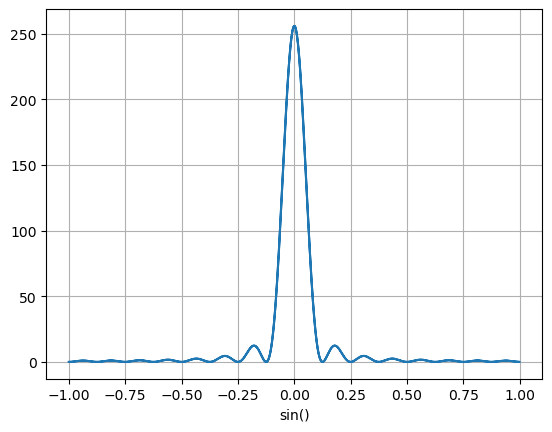

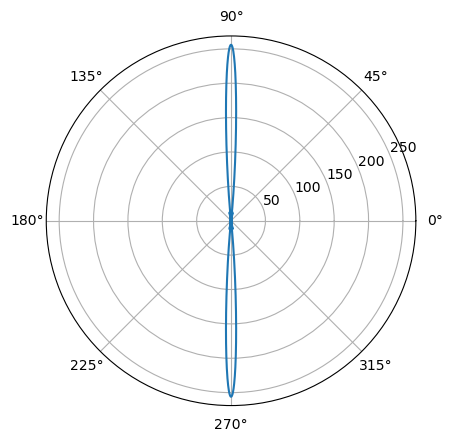

In [12]:
N = 16 # The number of antenna elements
d = 0.5 # wavelength equals to 1

visualize_antenna_pattern(np.ones(N,), N, d, 0)

## Steering vector: focus the energy towards some direction

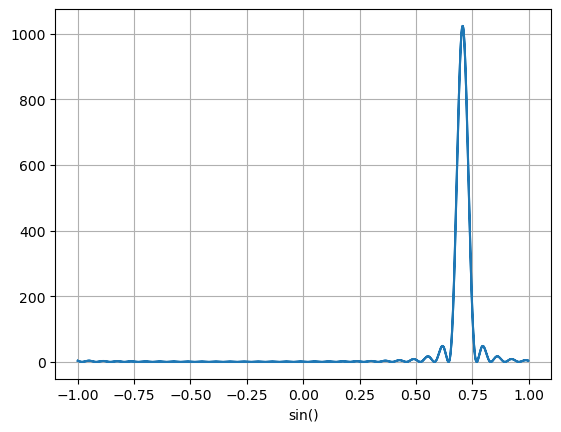

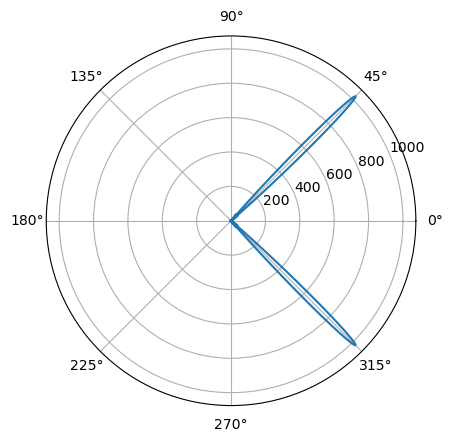

In [18]:
alpha = np.pi / 4  # Steering direction
N = 32
d = 0.5
w = np.exp(-d * np.cos(alpha) * 1j * np.pi * 2 * np.arange(0, N))

visualize_antenna_pattern(w, N, d, 0)

## Orthogonal basis of steering vectors

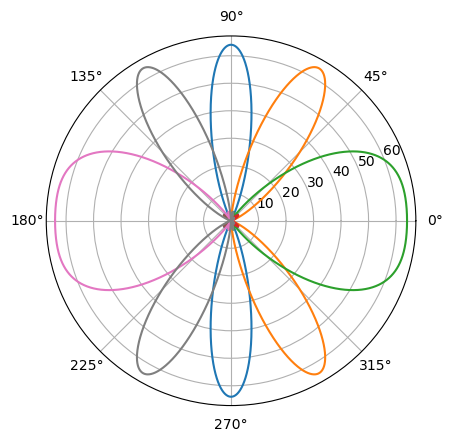

In [20]:
N = 8
d = 0.25
w = np.ones(N,)
plt.figure()

for k in range(N):
    w = np.exp(-2 * 1j * np.pi * np.arange(0, N) * k / (N))
    visualize_antenna_pattern(w, N, d)
# plt.legend([str(i) for i in range(N)])
plt.show()

# Signle transmit, and multiple receive antennas
# y = h * x + z
# h -- as a steering vector of the channel at the receiver
# h_a = W * h
# h_a = [1, 0, 0, 0.1]

## Steering and nulling
Suppose we have two users located at two different angles. Consider the LOS scenario. Let us construct two antenna patterns that minimize the interference between these two users (transmit beamforming)

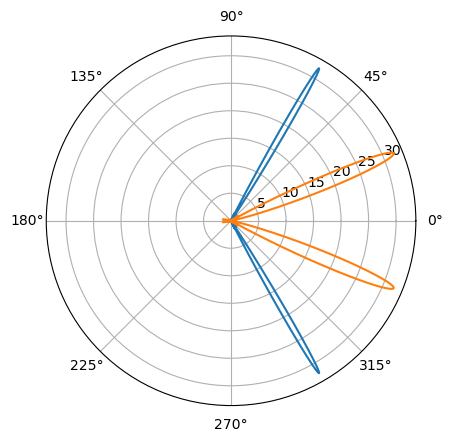

Before nulling
Steering angles dot product: 0.025129919598395476
#1: Signal power: 1.000, interference power: 0.001
#2: Signal power: 1.000, interference power: 0.001


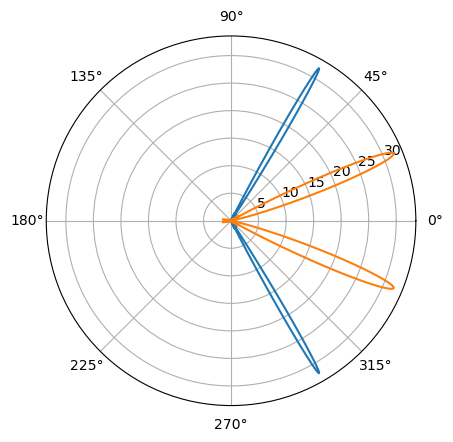

After nulling
Steering angles dot product: 0.029321074113966127
#1: Signal power: 0.999, interference power: 0.000
#2: Signal power: 0.999, interference power: 0.000


In [23]:
N = 32
d = 0.5
alpha1 = + np.pi / 3
alpha2 = + np.pi / 8
S1 = np.exp(-d * np.cos(alpha1) * 1j * np.pi * 2 * np.arange(0, N))
S2 = np.exp(-d * np.cos(alpha2) * 1j * np.pi * 2 * np.arange(0, N))

S1 = S1 / np.linalg.norm(S1)
S2 = S2 / np.linalg.norm(S2)

plt.figure()
visualize_antenna_pattern(S1, N, d)
visualize_antenna_pattern(S2, N, d)
plt.show()
print('Before nulling')
print('Steering angles dot product:', np.abs(np.dot(S1, S2)))
print('#1: Signal power: %1.3f, interference power: %1.3f' % (
    np.abs(np.dot(S1, np.conj(S1))) ** 2, 
    np.abs(np.dot(S2, np.conj(S1))) ** 2
))

print('#2: Signal power: %1.3f, interference power: %1.3f' % (
    np.abs(np.dot(S2, np.conj(S2))) ** 2, 
    np.abs(np.dot(S1, np.conj(S2))) ** 2
))

# Perform the interferene cancelling:
W = np.array([S1, S2])
w1 = np.dot(np.linalg.pinv(W), np.array([1, 0]))
w2 = np.dot(np.linalg.pinv(W), np.array([0, 1]))
# Normalize powers
w1 = np.conj(w1) / np.linalg.norm(w1)
w2 = np.conj(w2) / np.linalg.norm(w2)

# Visualize resulting antenna patterns:
plt.figure()
visualize_antenna_pattern(w1, N, d)
visualize_antenna_pattern(w2, N, d)
plt.show()

# Print signal and interference powers:
print('After nulling')
print('Steering angles dot product:', np.abs(np.dot(w1, w2)))
print('#1: Signal power: %1.3f, interference power: %1.3f' % (
    np.abs(np.dot(w1, np.conj(S1))) ** 2, 
    np.abs(np.dot(w2, np.conj(S1))) ** 2
))

print('#2: Signal power: %1.3f, interference power: %1.3f' % (
    np.abs(np.dot(w2, np.conj(S2))) ** 2, 
    np.abs(np.dot(w1, np.conj(S2))) ** 2
))